# YOLOv8 Semantic Segmentation on SAR-RARP50

**Dataset**: SAR-RARP50 subset (4 surgical videos, 539 annotated frames, 10 semantic classes)

**Model**: YOLOv8-nano segmentation, fine-tuned from COCO-pretrained weights

**Goal**: Train, evaluate, and interpret a YOLOv8 segmentation model on robotic surgery data.

Run cells **top-to-bottom**. All parameters are controlled by the `CONFIG` cell below.

In [35]:
import os, random, json, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
from ultralytics import YOLO

# ─── ALL TUNABLE PARAMETERS ──────────────────────────────────────────────────
CONFIG = {
    'videos_dir':   '../videos',
    'dataset_dir':  'datasets/sar_rarp50',
    'results_dir':  'runs/segment/results',
    'model':        'yolov8n-seg.pt',
    'epochs':       100,
    'imgsz':        640,
    'batch':        8,          # reduce to 4 if GPU VRAM < 6 GB
    'device':       0 if torch.cuda.is_available() else 'cpu',
    'amp':          True,       # FP16 mixed precision (RTX GPU)
    'patience':     20,
    'seed':         42,
    'test_video':   'video_12',
    'val_fraction': 0.2,
}

CLASS_NAMES = {
    0: 'background',
    1: 'bipolar_forceps',
    2: 'prograsp_forceps',
    3: 'large_needle_driver',
    4: 'vessel_sealer',
    5: 'grasping_retractor',
    6: 'monopolar_curved_scissors',
    7: 'ultrasound_probe',
    8: 'suction_instrument',
    9: 'suture_needle',
}

CLASS_COLORS = {
    0: (0,   0,   0),    # background — black
    1: (255, 0,   0),    # bipolar_forceps — red
    2: (0,   255, 0),    # prograsp_forceps — green
    3: (0,   0,   255),  # large_needle_driver — blue
    4: (255, 255, 0),    # vessel_sealer — yellow
    5: (255, 0,   255),  # grasping_retractor — magenta
    6: (0,   255, 255),  # monopolar_curved_scissors — cyan
    7: (128, 0,   255),  # ultrasound_probe — purple
    8: (255, 128, 0),    # suction_instrument — orange
    9: (0,   128, 255),  # suture_needle — light blue
}

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

print(f'Device: {CONFIG["device"]}  |  CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: 0  |  CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


---
## Section 0 — Setup & Dataset Exploration

### What is SAR-RARP50?

SAR-RARP50 is a robotic surgery dataset containing stereoscopic video of Robot-Assisted Radical
Prostatectomy (RARP) procedures. The **semantic segmentation** annotations label every pixel with
one of 10 class IDs (0 = background, 1–9 = surgical instruments/tissue).

We use a 4-video subset. Annotations exist at every 60th frame (sparse labelling).

### Semantic vs. Instance Segmentation

- **Semantic segmentation**: one label per pixel, across the whole image.
- **Instance segmentation** (YOLOv8's native output): separate mask per object instance.

We bridge the gap: convert semantic PNG masks → polygon contours per class instance → YOLO format.
At evaluation we rasterize instance predictions back into a semantic map to compute mIoU.

In [2]:
videos_root = Path(CONFIG['videos_dir'])
video_dirs = sorted([d for d in videos_root.iterdir() if d.is_dir()])

print('=== Dataset structure ===')
for vd in video_dirs:
    seg_files = sorted((vd / 'segmentation').glob('*.png'))
    print(f'{vd.name}: {len(seg_files)} annotated frames')
    for f in vd.iterdir():
        if f.is_file():
            print(f'  {f.name}')

total = sum(len(sorted((vd/'segmentation').glob('*.png'))) for vd in video_dirs)
print(f'\nTotal annotated frames: {total}')

=== Dataset structure ===
video_04: 131 annotated frames
  action_continuous.txt
  action_discrete.txt
  video_left.avi
video_08: 148 annotated frames
  action_continuous.txt
  action_discrete.txt
  video_left.avi
video_10: 128 annotated frames
  action_continuous.txt
  action_discrete.txt
  video_left.avi
video_12: 132 annotated frames
  action_continuous.txt
  action_discrete.txt
  video_left.avi

Total annotated frames: 539


In [3]:
print('=== Class distribution per video ===')
all_class_counts = {i: 0 for i in range(10)}

for vd in video_dirs:
    vid_counts = {i: 0 for i in range(10)}
    for mask_path in sorted((vd/'segmentation').glob('*.png')):
        mask = np.array(Image.open(mask_path))[:, :, 0]  # R channel = class ID
        unique, counts = np.unique(mask, return_counts=True)
        for u, c in zip(unique.tolist(), counts.tolist()):
            vid_counts[u] += c
            all_class_counts[u] += c
    present = [f'{CLASS_NAMES[k]}({k})' for k, v in vid_counts.items() if v > 0]
    print(f'{vd.name}: {present}')

print('\nNote: class 9 (suture_needle) only in video_12 — unseen during training!')

=== Class distribution per video ===
video_04: ['background(0)', 'bipolar_forceps(1)', 'prograsp_forceps(2)', 'large_needle_driver(3)', 'vessel_sealer(4)', 'grasping_retractor(5)', 'monopolar_curved_scissors(6)', 'ultrasound_probe(7)', 'suction_instrument(8)']
video_08: ['background(0)', 'bipolar_forceps(1)', 'prograsp_forceps(2)', 'large_needle_driver(3)', 'vessel_sealer(4)', 'grasping_retractor(5)', 'monopolar_curved_scissors(6)', 'ultrasound_probe(7)', 'suction_instrument(8)']
video_10: ['background(0)', 'bipolar_forceps(1)', 'prograsp_forceps(2)', 'large_needle_driver(3)', 'vessel_sealer(4)', 'grasping_retractor(5)', 'monopolar_curved_scissors(6)', 'ultrasound_probe(7)', 'suction_instrument(8)']
video_12: ['background(0)', 'bipolar_forceps(1)', 'prograsp_forceps(2)', 'large_needle_driver(3)', 'vessel_sealer(4)', 'grasping_retractor(5)', 'monopolar_curved_scissors(6)', 'ultrasound_probe(7)', 'suction_instrument(8)', 'suture_needle(9)']

Note: class 9 (suture_needle) only in video_12

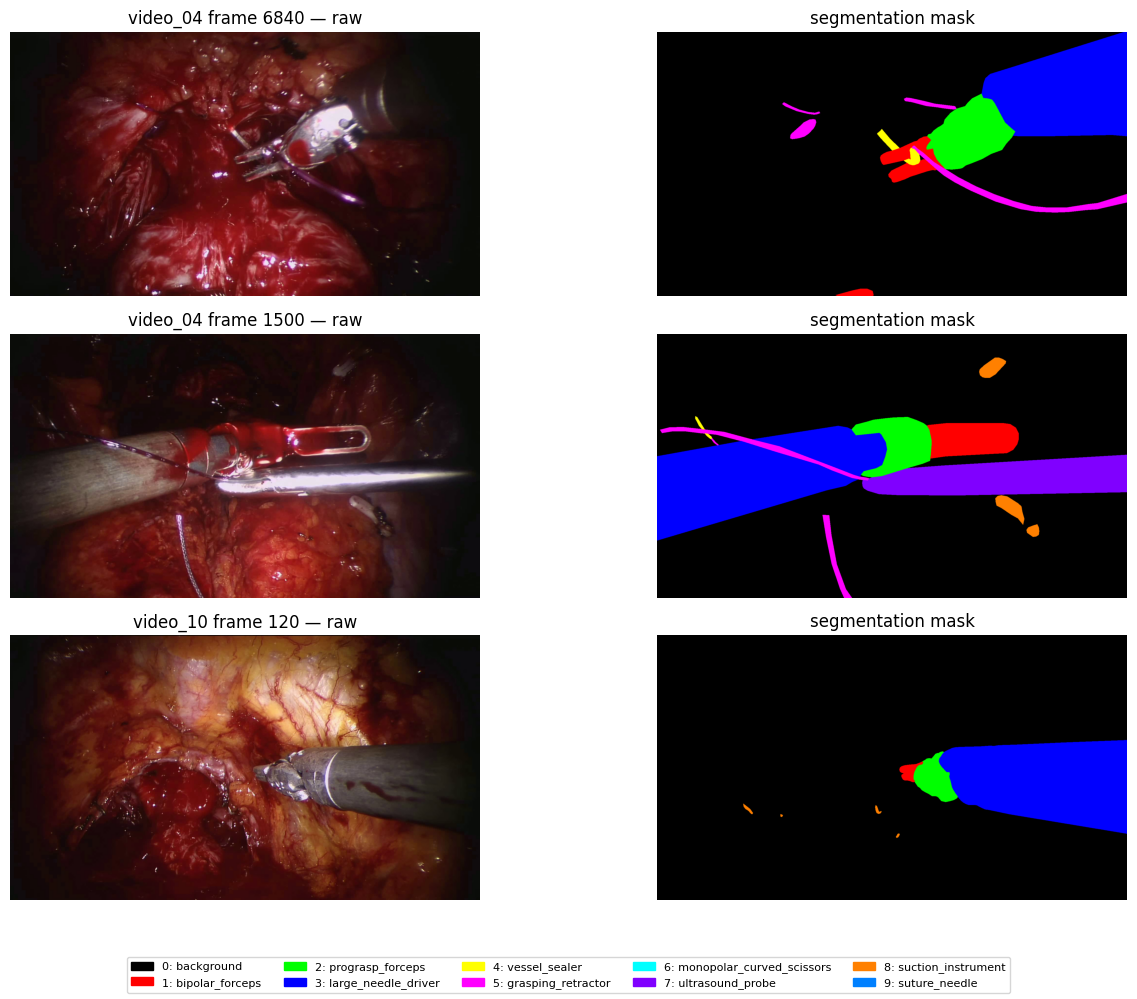

In [4]:
def colorize_mask(mask):
    h, w = mask.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in CLASS_COLORS.items():
        color_img[mask == cls_id] = color
    return color_img

all_pairs = []
for vd in video_dirs:
    for mp in sorted((vd/'segmentation').glob('*.png')):
        frame_num = int(mp.stem)
        all_pairs.append((vd/'video_left.avi', frame_num, mp))

chosen = random.sample(all_pairs, 3)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for row, (avi, fn, mp) in enumerate(chosen):
    cap = cv2.VideoCapture(str(avi))
    cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
    ret, frame = cap.read()
    cap.release()
    mask = np.array(Image.open(mp))[:, :, 0]
    color_mask = colorize_mask(mask)
    axes[row, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'{avi.parent.name} frame {fn} — raw')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(color_mask)
    axes[row, 1].set_title('segmentation mask')
    axes[row, 1].axis('off')

legend_patches = [mpatches.Patch(color=np.array(c)/255, label=f'{i}: {CLASS_NAMES[i]}')
                  for i, c in CLASS_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

---
## Section 1 — Data Pipeline: AVI → YOLO Polygon Format

### Why YOLO needs polygons, not pixel maps

YOLOv8 segmentation is trained with **polygon contours** (normalised x,y coordinates) rather
than raster pixel maps. Each contour describes one object instance's boundary.

**Label file format** (one line per instance):
```
<class_id> <x1> <y1> <x2> <y2> ... <xN> <yN>
```
All coordinates are normalised to [0, 1] relative to image width/height.
Background (class 0) is **never** written — unlabelled pixels are background by default.

### Split strategy
- **Test**: `video_12` held out entirely (never seen during training)
- **Train**: 80% of frames from `video_04`, `video_08`, `video_10`
- **Val**: remaining 20% of those frames

In [5]:
def extract_frame(avi_path, frame_number):
    """Extract one frame from an AVI by frame number."""
    cap = cv2.VideoCapture(str(avi_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f'Frame {frame_number} not found in {avi_path}')
    return frame  # BGR, shape (H, W, 3)

# Quick test
test_frame = extract_frame(
    videos_root / 'video_04' / 'video_left.avi', 0
)
print(f'Frame shape: {test_frame.shape}, dtype: {test_frame.dtype}')

Frame shape: (1080, 1920, 3), dtype: uint8


In [6]:
def mask_to_yolo_polygons(mask_path, min_area=100, epsilon=2.0):
    """
    Convert a semantic PNG mask to YOLO polygon label lines.
    Returns list of strings, one per polygon: 'class_id x1 y1 x2 y2 ...'
    """
    mask = np.array(Image.open(mask_path))[:, :, 0].astype(np.uint8)
    h, w = mask.shape
    lines = []

    for cls_id in range(1, 10):  # skip background (0)
        binary = np.where(mask == cls_id, 255, 0).astype(np.uint8)
        if binary.max() == 0:
            continue
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue
            approx = cv2.approxPolyDP(cnt, epsilon, True)
            if len(approx) < 3:
                continue
            pts = approx.reshape(-1, 2)
            norm_pts = pts / np.array([w, h], dtype=np.float32)
            coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in norm_pts)
            lines.append(f'{cls_id} {coords}')
    return lines

# Quick test
test_mask = videos_root / 'video_04' / 'segmentation' / '000000060.png'
polys = mask_to_yolo_polygons(test_mask)
print(f'Found {len(polys)} polygon(s) in test mask')
if polys:
    print(f'Example: {polys[0][:80]}...')

Found 2 polygon(s) in test mask
Example: 1 0.437500 0.737037 0.436979 0.710185 0.433333 0.693519 0.428646 0.681481 0.4145...


In [7]:
# Build list of (avi_path, frame_number, mask_path, split) tuples
test_video = CONFIG['test_video']
val_frac   = CONFIG['val_fraction']

train_val_frames = []
test_frames      = []

for vd in video_dirs:
    avi = vd / 'video_left.avi'
    masks = sorted((vd / 'segmentation').glob('*.png'))
    for mp in masks:
        entry = (avi, int(mp.stem), mp)
        if vd.name == test_video:
            test_frames.append(entry)
        else:
            train_val_frames.append(entry)

random.shuffle(train_val_frames)
n_val   = int(len(train_val_frames) * val_frac)
val_frames   = train_val_frames[:n_val]
train_frames = train_val_frames[n_val:]

splits = {'train': train_frames, 'val': val_frames, 'test': test_frames}
for s, flist in splits.items():
    print(f'{s:5s}: {len(flist):4d} frames')
print(f'Total: {sum(len(v) for v in splits.values())} frames')

train:  326 frames
val  :   81 frames
test :  132 frames
Total: 539 frames


In [8]:
# Write images + labels to datasets/sar_rarp50/
dataset_root = Path(CONFIG['dataset_dir'])

for split_name, frame_list in splits.items():
    img_dir = dataset_root / 'images' / split_name
    lbl_dir = dataset_root / 'labels' / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for avi_path, frame_num, mask_path in frame_list:
        video_name = avi_path.parent.name
        stem = f'{video_name}_{frame_num:09d}'

        # Extract and save JPEG frame
        frame = extract_frame(avi_path, frame_num)
        cv2.imwrite(str(img_dir / f'{stem}.jpg'), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

        # Convert mask to YOLO polygons and save label
        polygon_lines = mask_to_yolo_polygons(mask_path)
        with open(lbl_dir / f'{stem}.txt', 'w') as f:
            f.write('\n'.join(polygon_lines))

    print(f'[OK] {split_name}: {len(frame_list)} images/labels written to {img_dir}')

[OK] train: 326 images/labels written to datasets\sar_rarp50\images\train
[OK] val: 81 images/labels written to datasets\sar_rarp50\images\val
[OK] test: 132 images/labels written to datasets\sar_rarp50\images\test


In [9]:
import yaml

dataset_yaml = {
    'path':  str(dataset_root.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    10,
    'names': CLASS_NAMES,
}

yaml_path = dataset_root / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print(f'dataset.yaml written to {yaml_path}')
print(f'\nSplit summary:')
print(f'  train: {len(train_frames)} frames (video_04, video_08, video_10 — 80%)')
print(f'  val:   {len(val_frames)} frames (video_04, video_08, video_10 — 20%)')
print(f'  test:  {len(test_frames)} frames (video_12, held-out entirely)')

dataset.yaml written to datasets\sar_rarp50\dataset.yaml

Split summary:
  train: 326 frames (video_04, video_08, video_10 — 80%)
  val:   81 frames (video_04, video_08, video_10 — 20%)
  test:  132 frames (video_12, held-out entirely)


---
## Section 2 — YOLOv8 Architecture Walkthrough

This section walks through every major building block of YOLOv8 from **first principles**.
Each sub-section contains:
1. **The concept** — what this block does and *why* it exists
2. **A plain-language analogy** — to build an intuition without prior CV knowledge
3. **A runnable code cell** — to inspect the real module from the Ultralytics library

The full architecture is: **Backbone (CBS → Bottleneck → C2f → SPPF) → PANet Neck → Decoupled Head + Proto**

### 2.1 CBS — Conv + BatchNorm + SiLU (The Lego Brick)

**What it does**: Every feature map in YOLOv8 is produced by stacking *CBS* blocks.
- **Conv** (2D convolution): a sliding window that learns to detect local patterns (edges, textures).
  Think of it as a stamp that drags across the image looking for a specific shape.
- **BatchNorm**: after each convolution, normalises activations so every layer 'speaks the same
  language'. Analogy: imagine normalising exam scores so all classes have mean=0, std=1.
- **SiLU** (`x · σ(x)`): a smooth non-linearity. Unlike ReLU (which hard-clips at 0), SiLU
  tapers softly — it passes strong positive signals fully and suppresses near-zero ones gently.

**Why Conv+BN+Act together?** Without BN, deep stacks collapse (vanishing/exploding gradients).
Without a non-linearity, stacking convolutions is equivalent to one big convolution — no
expressive power gained.

In [10]:
from ultralytics.nn.modules.conv import Conv

cbs = Conv(c1=3, c2=64, k=3, s=1)
print('CBS block structure:')
print(cbs)
n_params = sum(p.numel() for p in cbs.parameters())
print(f'\nTotal parameters: {n_params:,}')

# Trace a dummy input
x = torch.randn(1, 3, 64, 64)
out = cbs(x)
print(f'Input shape:  {tuple(x.shape)}')
print(f'Output shape: {tuple(out.shape)}')

CBS block structure:
Conv(
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): SiLU()
)

Total parameters: 1,856
Input shape:  (1, 3, 64, 64)
Output shape: (1, 64, 64, 64)


### 2.2 Bottleneck (Compress → Enrich → Expand)

**What it does**: Two CBS blocks (1×1 then 3×3) that squeeze the channel dimension then expand it,
optionally with a **residual (skip) connection**.

- **1×1 conv**: channel compression (cheaper computation — fewer channels to process).
- **3×3 conv**: spatial feature extraction on the compressed representation.
- **Skip connection**: if the block adds little new information, the shortcut 'skips' the
  computation and propagates the original signal unchanged. This also provides a direct highway
  for gradients during backpropagation — preventing them from vanishing in deep networks.

**Analogy**: Read a chapter summary (1×1), extract the key points (3×3). If the key points
don't add value over the summary, skip and pass the summary directly to the next reader.

In [11]:
from ultralytics.nn.modules.block import Bottleneck

bn = Bottleneck(c1=64, c2=64, shortcut=True)
print('Bottleneck structure:')
print(bn)

x = torch.randn(1, 64, 32, 32)
out = bn(x)
print(f'\nInput:  {tuple(x.shape)}')
print(f'Output: {tuple(out.shape)}')

n_params_bn = sum(p.numel() for p in bn.parameters())
plain_conv   = Conv(64, 64, 3)
n_params_conv = sum(p.numel() for p in plain_conv.parameters())
print(f'\nBottleneck params: {n_params_bn:,}  vs  plain 3x3 Conv: {n_params_conv:,}')

Bottleneck structure:
Bottleneck(
  (cv1): Conv(
    (conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
  (cv2): Conv(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
)

Input:  (1, 64, 32, 32)
Output: (1, 64, 32, 32)

Bottleneck params: 37,056  vs  plain 3x3 Conv: 36,992


### 2.3 C2f — Cross Stage Partial with 2 Fused Outputs

**What it does**: The backbone's main feature extractor. Splits the input into two paths:
- **Deep path**: N stacked Bottleneck blocks that build up increasingly abstract features.
- **Shortcut path**: the original tensor passed directly, unchanged.
Both paths — plus the output of *every* Bottleneck block — are concatenated and projected
through a final 1×1 conv.

**Why concatenate intermediates?** Early layers detect edges; middle layers detect shapes;
later layers detect semantic concepts. By keeping all intermediate representations, the
network can simultaneously leverage low-level geometry and high-level semantics.

**Analogy**: A relay race where every runner's baton is saved. At the finish line you have
all batons, not just the last one — so judges can assess speed at every stage.

In [12]:
from ultralytics.nn.modules.block import C2f

c2f = C2f(c1=64, c2=128, n=3, shortcut=True)
print('C2f structure:')
print(c2f)

x = torch.randn(1, 64, 80, 80)
out = c2f(x)
print(f'\nInput:  {tuple(x.shape)}')
print(f'Output: {tuple(out.shape)}')
print(f'Parameters: {sum(p.numel() for p in c2f.parameters()):,}')

C2f structure:
C2f(
  (cv1): Conv(
    (conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
  (cv2): Conv(
    (conv): Conv2d(320, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
  (m): ModuleList(
    (0-2): 3 x Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU()
      )
      (cv2): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU()
      )
    )
  )
)

Input:  (1, 64, 80, 80)
Output: (1, 128,

### 2.4 SPPF — Spatial Pyramid Pooling Fast

**What it does**: Applied at the bottom of the backbone (deepest, smallest feature map). Runs
the same 5×5 max-pool **three times sequentially** and concatenates all four tensors (original
+ 3 pooled versions). This effectively creates receptive fields of 5, 9, and 13 pixels in a
single efficient pass.

**Why multi-scale pooling?** Surgical instruments vary enormously in size and orientation.
A thin suction tube needs a small receptive field; a large needle driver needs a wide one.
SPPF lets the network 'see' each scale simultaneously without needing multiple passes.

**Analogy**: Looking at a map at three zoom levels (street, district, city) all at once,
then combining the view.

In [13]:
from ultralytics.nn.modules.block import SPPF

sppf = SPPF(c1=512, c2=512, k=5)
print('SPPF structure:')
print(sppf)

x = torch.randn(1, 512, 20, 20)
out = sppf(x)
print(f'\nInput:  {tuple(x.shape)}')
print(f'Output: {tuple(out.shape)}  (channels ×2 due to concatenation)')

SPPF structure:
SPPF(
  (cv1): Conv(
    (conv): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): Identity()
  )
  (cv2): Conv(
    (conv): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
  (m): MaxPool2d(kernel_size=5, stride=1, padding=2, dilation=1, ceil_mode=False)
)

Input:  (1, 512, 20, 20)
Output: (1, 512, 20, 20)  (channels ×2 due to concatenation)


### 2.5 Full Backbone — Putting It Together

The YOLOv8 backbone is a stack of CBS → C2f → C2f → C2f → C2f → SPPF blocks, with
downsampling (stride-2 convolutions) at each stage.

**Feature map sizes** (for 640×640 input):
```
Input:  640 × 640 × 3
P1:     320 × 320 × 16
P2:     160 × 160 × 32
P3:      80 ×  80 × 64    ← used by neck (small objects)
P4:      40 ×  40 × 128   ← used by neck (medium objects)
P5:      20 ×  20 × 256   ← SPPF output, used by neck (large objects)
```
Deeper = smaller spatial resolution but richer semantic content.

In [14]:
model = YOLO(CONFIG['model'])
print('YOLOv8n-seg backbone layers (indices 0–9):')
print('-' * 60)
for i, layer in enumerate(model.model.model[:10]):
    n_p = sum(p.numel() for p in layer.parameters())
    print(f'[{i:2d}] {type(layer).__name__:25s}  params={n_p:>8,}')

# Trace feature map sizes through backbone
print('\nFeature map sizes through backbone:')
x = torch.randn(1, 3, 640, 640)
model_layers = list(model.model.model)
for i in range(10):
    try:
        x = model_layers[i](x)
        print(f'  After layer {i:2d} ({type(model_layers[i]).__name__:20s}): {tuple(x.shape)}')
    except Exception:
        break

YOLOv8n-seg backbone layers (indices 0–9):
------------------------------------------------------------
[ 0] Conv                       params=     464
[ 1] Conv                       params=   4,672
[ 2] C2f                        params=   7,360
[ 3] Conv                       params=  18,560
[ 4] C2f                        params=  49,664
[ 5] Conv                       params=  73,984
[ 6] C2f                        params= 197,632
[ 7] Conv                       params= 295,424
[ 8] C2f                        params= 460,288
[ 9] SPPF                       params= 164,608

Feature map sizes through backbone:
  After layer  0 (Conv                ): (1, 16, 320, 320)
  After layer  1 (Conv                ): (1, 32, 160, 160)
  After layer  2 (C2f                 ): (1, 32, 160, 160)
  After layer  3 (Conv                ): (1, 64, 80, 80)
  After layer  4 (C2f                 ): (1, 64, 80, 80)
  After layer  5 (Conv                ): (1, 128, 40, 40)
  After layer  6 (C2f         

### 2.6 PANet Neck — Feature Pyramid

The neck fuses backbone features at three scales (P3/P4/P5) into three enriched output maps.

**Top-down path (FPN-style)**: Takes P5 (deep, semantic, low-res) and upsamples it, then
concatenates with P4. Does the same for P4+P3. Result: small feature maps now have global context.
> *'The overview map guides the street-level detail.'*

**Bottom-up path**: Takes the merged P3, downsamples, concatenates with P4 again. Does the
same for P4+P5. Result: the large feature maps now benefit from fine spatial structure.
> *'The street-level detail corrects the overview.'*

**Why two paths?** A single top-down pass loses fine-grained position information in the
upsampled layers. The bottom-up pass adds it back — critical for precise instrument localisation.

In [15]:
print('YOLOv8n-seg neck + head layers (indices 10+):')
print('-' * 60)
for i, layer in enumerate(model.model.model[10:], start=10):
    n_p = sum(p.numel() for p in layer.parameters())
    print(f'[{i:2d}] {type(layer).__name__:30s}  params={n_p:>8,}')

YOLOv8n-seg neck + head layers (indices 10+):
------------------------------------------------------------
[10] Upsample                        params=       0
[11] Concat                          params=       0
[12] C2f                             params= 148,224
[13] Upsample                        params=       0
[14] Concat                          params=       0
[15] C2f                             params=  37,248
[16] Conv                            params=  36,992
[17] Concat                          params=       0
[18] C2f                             params= 123,648
[19] Conv                            params= 147,712
[20] Concat                          params=       0
[21] C2f                             params= 493,056
[22] Segment                         params=1,150,432


### 2.7 Decoupled Segmentation Head (cv2 + cv3)

YOLOv8 uses a **decoupled head** — separate branches for detection and segmentation:

- **cv2 branch** (box prediction): 2 CBS blocks → 1×1 conv → bounding-box coordinates
  (DFL format) and class scores. Answers: *where is it? what class?*
- **cv3 branch** (mask coefficients): 2 CBS blocks → 1×1 conv → 32 floating-point coefficients
  per detection. Answers: *what is its exact shape?*

**Why decoupled?** YOLOv5 and earlier used a single coupled head. Experiments showed that
localisation and classification benefit from separate gradient flows — the decoupled head
consistently improves mAP without adding many parameters.

In [16]:
# The detection head is the last module in the model
head = model.model.model[-1]
print(f'Head type: {type(head).__name__}')
print(f'Number of output scales: {head.nl}')
print(f'Number of prototype masks: {head.nm}')

# Run a prediction on a test frame
test_frame_rgb = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)
results = model.predict(test_frame_rgb, device=CONFIG['device'], verbose=False, conf=0.1)
r = results[0]
print(f'\nPrediction output keys: {r.__class__.__name__}')
print(f'  Detected instances: {len(r.boxes) if r.boxes is not None else 0}')
if r.masks is not None:
    print(f'  Mask array shape: {r.masks.data.shape}  (N, H, W)')
    print(f'  Box cls shape:    {r.boxes.cls.shape}')

Head type: Segment
Number of output scales: 3
Number of prototype masks: 32

Prediction output keys: Results
  Detected instances: 1
  Mask array shape: torch.Size([1, 384, 640])  (N, H, W)
  Box cls shape:    torch.Size([1])


### 2.8 Proto — Prototype Mask Network

**What it does**: A small FCN that runs on P3 (the highest-resolution neck output) and produces
32 **prototype masks** of shape (32, H/4, W/4).

At inference each detected instance gets 32 **mask coefficients** (from cv3 branch). The final
instance mask is a weighted sum of all 32 prototypes using those coefficients:
```
instance_mask = sigmoid(coefficients @ prototypes)   # shape (H/4, W/4)
```

**Why prototypes?** Predicting a full H×W binary mask per instance would be very expensive.
Prototypes are shared across all instances — the network learns 32 generic shapes, and each
instance is described by how to blend them.

**Analogy**: 32 cookie-cutter shapes. Every surgical instrument mask is described as a
weighted combination of these templates.

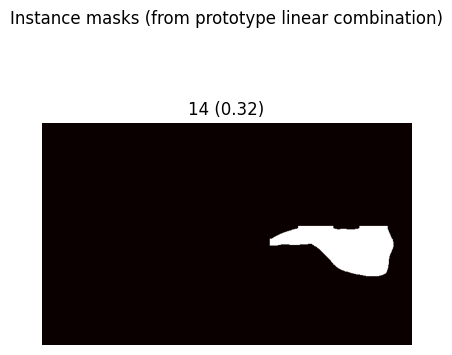

In [17]:
# Visualise prototype masks if we have detected instances
if r.masks is not None and len(r.masks.data) > 0:
    # masks.data: (N_instances, H, W) — already rasterized by ultralytics
    # Show first 4 instance masks as a grid
    n_show = min(4, len(r.masks.data))
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for idx in range(n_show):
        mask_np = r.masks.data[idx].cpu().numpy()
        cls_id  = int(r.boxes.cls[idx].item())
        conf    = float(r.boxes.conf[idx].item())
        axes[idx].imshow(mask_np, cmap='hot')
        axes[idx].set_title(f'{CLASS_NAMES.get(cls_id, cls_id)} ({conf:.2f})')
        axes[idx].axis('off')
    plt.suptitle('Instance masks (from prototype linear combination)', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No instances detected in test frame — try lowering conf threshold or using a trained model.')

### 2.9 DFL — Distribution Focal Loss

**What it does**: Instead of predicting a single scalar for each box coordinate (e.g., distance
from anchor to left edge), DFL predicts a **probability distribution** over 16 discrete bins.
The expected value (softmax-weighted sum) gives the coordinate.

**Why a distribution?** Box boundaries are often ambiguous — a surgical instrument edge might
be partially occluded or blurry. A distribution captures this uncertainty: instead of
confidently predicting one wrong number, the model can express 'probably around bin 5 or 6'.

**Formula**:
```
predicted_coordinate = Σ (bin_value_i × softmax(logit_i))  for i in 0..15
```

**Analogy**: Asking 16 people to each vote on where the left edge of an object is, then
taking the weighted average of their votes — instead of trusting a single estimator.

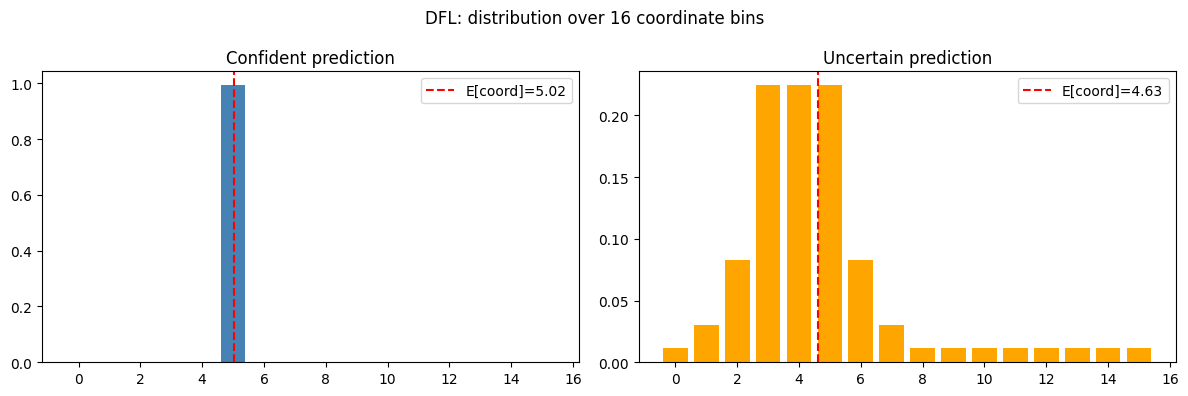

In [18]:
# Visualise what a DFL prediction looks like
n_bins = 16
bins   = np.arange(n_bins, dtype=float)

# Simulate two example distributions: confident vs. uncertain
logits_confident  = np.array([0, 0, 0, 0, 0, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float)
logits_uncertain  = np.array([0, 1, 2, 3, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

probs_conf = softmax(logits_confident)
probs_unc  = softmax(logits_uncertain)

pred_conf = (probs_conf * bins).sum()
pred_unc  = (probs_unc  * bins).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bins, probs_conf, color='steelblue')
axes[0].axvline(pred_conf, color='red', linestyle='--', label=f'E[coord]={pred_conf:.2f}')
axes[0].set_title('Confident prediction')
axes[0].legend()
axes[1].bar(bins, probs_unc, color='orange')
axes[1].axvline(pred_unc, color='red', linestyle='--', label=f'E[coord]={pred_unc:.2f}')
axes[1].set_title('Uncertain prediction')
axes[1].legend()
plt.suptitle('DFL: distribution over 16 coordinate bins')
plt.tight_layout()
plt.show()

### 2.10 End-to-End Forward Pass

Let's run the full pipeline on one test frame and inspect the output structure.
The `Results` object contains:
- `boxes`: bounding boxes (xyxy, cls, conf)
- `masks`: per-instance binary masks at image resolution
- `orig_img`: the original image


0: 384x640 1 bird, 11.1ms
Speed: 1.8ms preprocess, 11.1ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

=== Output structure ===
boxes.xyxy shape:  torch.Size([1, 4])   (x1,y1,x2,y2)
boxes.cls  shape:  torch.Size([1])    (class IDs)
boxes.conf shape:  torch.Size([1])   (confidences)
masks.data shape:  torch.Size([1, 384, 640])  (N, H, W)


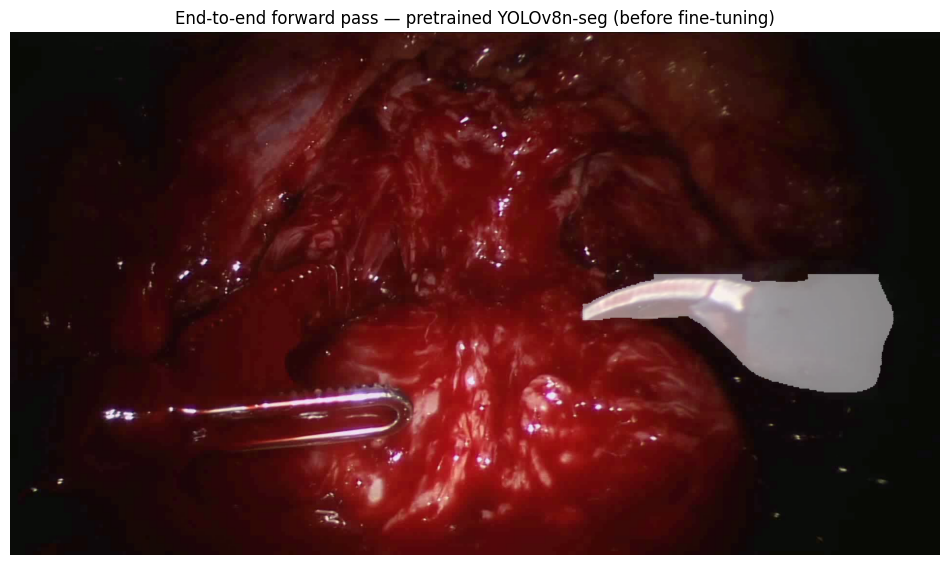

In [19]:
results = model.predict(test_frame_rgb, device=CONFIG['device'], conf=0.05, verbose=True)
r = results[0]

print('\n=== Output structure ===')
if r.boxes is not None:
    print(f'boxes.xyxy shape:  {r.boxes.xyxy.shape}   (x1,y1,x2,y2)')
    print(f'boxes.cls  shape:  {r.boxes.cls.shape}    (class IDs)')
    print(f'boxes.conf shape:  {r.boxes.conf.shape}   (confidences)')
if r.masks is not None:
    print(f'masks.data shape:  {r.masks.data.shape}  (N, H, W)')

# Overlay all detected masks on the test frame
overlay = test_frame_rgb.copy()
if r.masks is not None:
    for i, mask in enumerate(r.masks.data.cpu().numpy()):
        cls_id = int(r.boxes.cls[i].item())
        color  = CLASS_COLORS.get(cls_id, (255, 255, 255))
        m = cv2.resize(mask, (overlay.shape[1], overlay.shape[0]))
        overlay[m > 0.5] = (np.array(overlay[m > 0.5], dtype=float) * 0.5
                            + np.array(color) * 0.5).astype(np.uint8)

plt.figure(figsize=(12, 7))
plt.imshow(overlay)
plt.title('End-to-end forward pass — pretrained YOLOv8n-seg (before fine-tuning)')
plt.axis('off')
plt.show()

---
## Section 3 — Training on SAR-RARP50 (RTX GPU)

### Transfer learning rationale

We have only ~407 training frames — far too few to train from scratch. We start from
`yolov8n-seg.pt`, pretrained on COCO (80 classes, ~118k images). The backbone already knows
how to detect edges, textures, and shapes; we only need to adapt it to surgical instruments.

### FP16 mixed precision (`amp=True`)

On RTX GPUs, FP16 arithmetic is ~2× faster than FP32 and uses half the VRAM with negligible
accuracy loss. Ultralytics handles the precision scaling automatically.

### Early stopping (`patience=20`)

If val mAP does not improve for 20 consecutive epochs, training stops early. This prevents
overfitting on our small dataset.

In [ ]:
import yaml as _yaml

train_model = YOLO(CONFIG['model'])

train_results = train_model.train(
    data    = str((Path(CONFIG['dataset_dir']) / 'dataset.yaml').resolve()),
    epochs  = CONFIG['epochs'],
    imgsz   = CONFIG['imgsz'],
    batch   = CONFIG['batch'],
    device  = CONFIG['device'],
    amp     = CONFIG['amp'],
    patience= CONFIG['patience'],
    seed    = CONFIG['seed'],
    project = CONFIG['results_dir'],
    name    = 'train',
    exist_ok= True,
)

# Capture the actual save directory (Ultralytics may prefix runs/segment/)
save_dir = Path(train_model.trainer.save_dir)
CONFIG['results_dir'] = str(save_dir.parent)

best_ckpt = save_dir / 'weights' / 'best.pt'
print(f'\n[OK] Training complete.')
print(f'     Save directory:  {save_dir}')
print(f'     Best checkpoint: {best_ckpt}')

In [32]:
results_csv = Path(CONFIG['results_dir']) / 'train' / 'results.csv'
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
loss_cols = [c for c in df.columns if 'loss' in c.lower()]
for col in loss_cols:
    if 'train' in col or 'val' in col:
        axes[0].plot(df['epoch'], df[col], label=col)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(fontsize=8)

# mAP curve
map_cols = [c for c in df.columns if 'map' in c.lower() or 'miou' in c.lower()]
for col in map_cols:
    axes[1].plot(df['epoch'], df[col], label=col)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP / mIoU')
axes[1].set_title('Validation mAP')
axes[1].legend(fontsize=8)

plt.tight_layout()
out_fig = Path(CONFIG['results_dir']) / 'train' / 'training_curves.png'
plt.savefig(out_fig, dpi=150)
plt.show()
print(f'Training curves saved to {out_fig}')

FileNotFoundError: [Errno 2] No such file or directory: 'results\\train\\results.csv'

---
## Section 4 — Evaluation on Test Set (video_12)

### Strategy: instance predictions → semantic map

YOLOv8 returns per-instance masks. To compute semantic mIoU we need a single per-pixel
class map. We rasterize all instance masks, using **confidence priority** when instances
overlap: the highest-confidence instance wins each pixel.

### Note on class 9 (suture_needle)

Class 9 appears only in `video_12` (our test set). The model was never trained on it, so
its IoU is expected to be ~0. We report it separately and flag it as *unseen-in-training*.

In [36]:
best_ckpt = Path(CONFIG['results_dir']) / 'train' / 'weights' / 'best.pt'
eval_model = YOLO(str(best_ckpt))

test_img_dir = Path(CONFIG['dataset_dir']) / 'images' / 'test'
test_lbl_dir = Path(CONFIG['dataset_dir']) / 'labels' / 'test'
test_images  = sorted(test_img_dir.glob('*.jpg'))

print(f'Evaluating on {len(test_images)} test frames from video_12...')
gt_masks_all   = []
pred_masks_all = []

for img_path in test_images:
    # Ground-truth semantic mask
    stem = img_path.stem  # e.g. video_12_000001200
    video_id = '_'.join(stem.split('_')[:2])  # video_12
    fn_str   = stem.split('_')[-1]           # 000001200
    gt_mask_path = Path(CONFIG['videos_dir']) / video_id / 'segmentation' / f'{fn_str}.png'
    gt_mask = np.array(Image.open(gt_mask_path))[:, :, 0].astype(np.uint8)

    # Model prediction
    frame = cv2.imread(str(img_path))
    results = eval_model.predict(frame, device=CONFIG['device'], conf=0.25, verbose=False)
    r = results[0]

    gt_masks_all.append(gt_mask)
    pred_masks_all.append((r, gt_mask.shape))

print(f'Inference complete on {len(test_images)} frames.')

Evaluating on 132 test frames from video_12...
Inference complete on 132 frames.


In [37]:
def results_to_semantic(result, h, w):
    """
    Convert YOLOv8 instance segmentation result to a semantic (H, W) class-ID map.
    Pixels with no instance prediction stay as 0 (background).
    Overlapping instances: highest-confidence instance wins.
    """
    canvas = np.zeros((h, w), dtype=np.uint8)
    if result.masks is None or len(result.masks.data) == 0:
        return canvas

    # Sort by confidence ascending so highest conf overwrites last
    confs   = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    masks   = result.masks.data.cpu().numpy()  # (N, Hm, Wm)

    order = np.argsort(confs)  # lowest confidence first
    for i in order:
        m = cv2.resize(masks[i], (w, h))
        canvas[m > 0.5] = classes[i]
    return canvas

# Rasterize all test predictions
pred_semantic_all = []
for (r, shape) in pred_masks_all:
    h, w = shape
    pred_semantic_all.append(results_to_semantic(r, h, w))

print(f'Rasterized {len(pred_semantic_all)} semantic maps.')

Rasterized 132 semantic maps.


In [38]:
n_classes = 10
intersection = np.zeros(n_classes, dtype=np.int64)
union        = np.zeros(n_classes, dtype=np.int64)
total_correct = 0
total_pixels  = 0

for gt, pred in zip(gt_masks_all, pred_semantic_all):
    for c in range(n_classes):
        gt_c   = (gt == c)
        pred_c = (pred == c)
        intersection[c] += (gt_c & pred_c).sum()
        union[c]        += (gt_c | pred_c).sum()
    total_correct += (gt == pred).sum()
    total_pixels  += gt.size

per_class_iou = np.where(union > 0, intersection / union, np.nan)
miou          = np.nanmean(per_class_iou)
miou_no_bg    = np.nanmean(per_class_iou[1:])
pixel_acc     = total_correct / total_pixels

print(f'\n=== Evaluation Results (video_12 test set, {len(gt_masks_all)} frames) ===')
print(f'mIoU (all classes):    {miou:.4f}')
print(f'mIoU (no background):  {miou_no_bg:.4f}')
print(f'Pixel accuracy:        {pixel_acc:.4f}')
print(f'\nPer-class IoU:')
print(f'{"Class":35s}  {"IoU":>7}  Note')
print('-' * 60)
for c in range(n_classes):
    iou_val = per_class_iou[c]
    note    = '(unseen in training)' if c == 9 else ''
    iou_str = f'{iou_val:.4f}' if not np.isnan(iou_val) else '   N/A'
    print(f'{c}: {CLASS_NAMES[c]:30s}  {iou_str:>7}  {note}')


=== Evaluation Results (video_12 test set, 132 frames) ===
mIoU (all classes):    0.3889
mIoU (no background):  0.3283
Pixel accuracy:        0.9363

Per-class IoU:
Class                                    IoU  Note
------------------------------------------------------------
0: background                       0.9344  
1: bipolar_forceps                  0.5566  
2: prograsp_forceps                 0.6356  
3: large_needle_driver              0.8482  
4: vessel_sealer                    0.2777  
5: grasping_retractor               0.1437  
6: monopolar_curved_scissors        0.0344  
7: ultrasound_probe                 0.4359  
8: suction_instrument               0.0224  
9: suture_needle                    0.0000  (unseen in training)


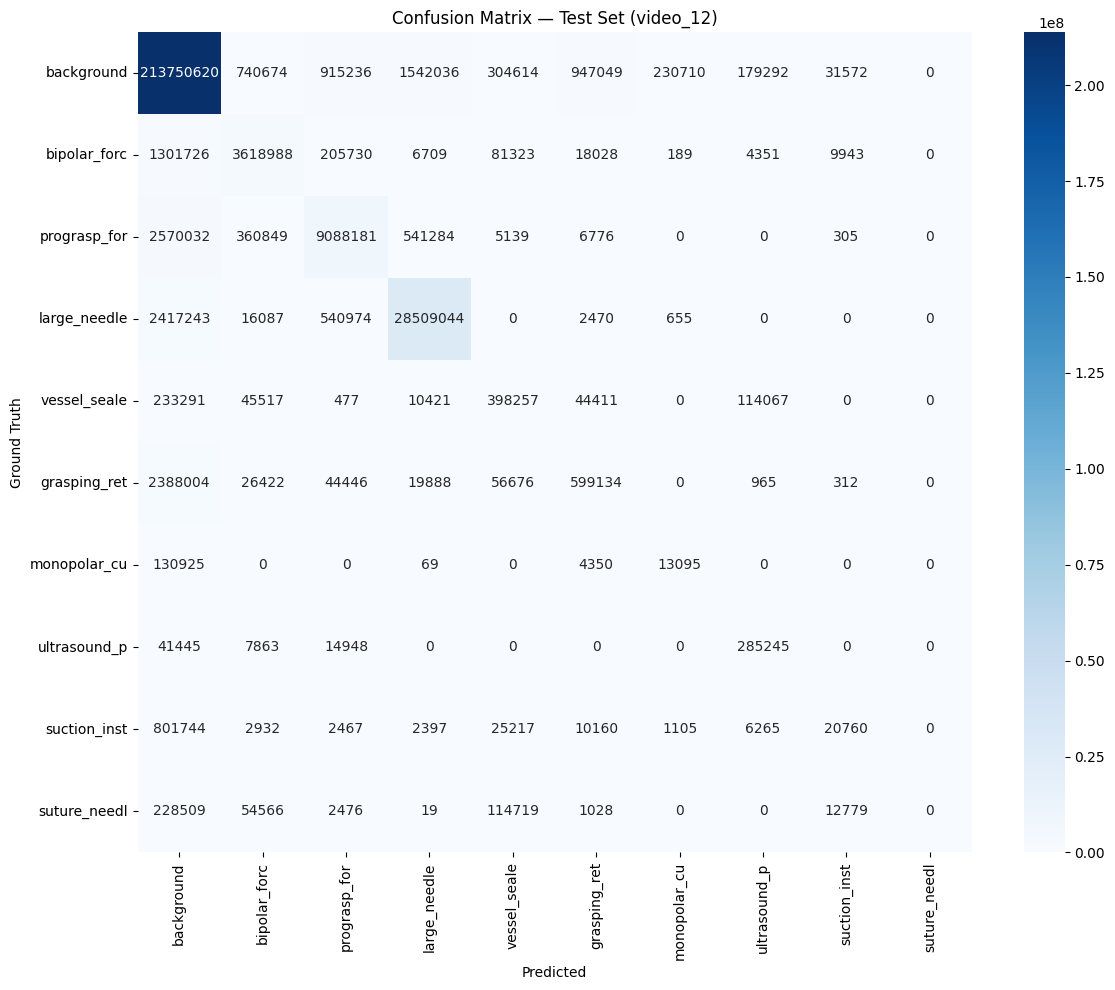

Confusion matrix saved to runs\segment\results\train\confusion_matrix_test.png


In [39]:
gt_flat   = np.concatenate([g.ravel() for g in gt_masks_all])
pred_flat = np.concatenate([p.ravel() for p in pred_semantic_all])

cm = confusion_matrix(gt_flat, pred_flat, labels=list(range(n_classes)))

short_names = [CLASS_NAMES[i][:12] for i in range(n_classes)]
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Confusion Matrix — Test Set (video_12)')
plt.tight_layout()
cm_path = Path(CONFIG['results_dir']) / 'train' / 'confusion_matrix_test.png'
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'Confusion matrix saved to {cm_path}')

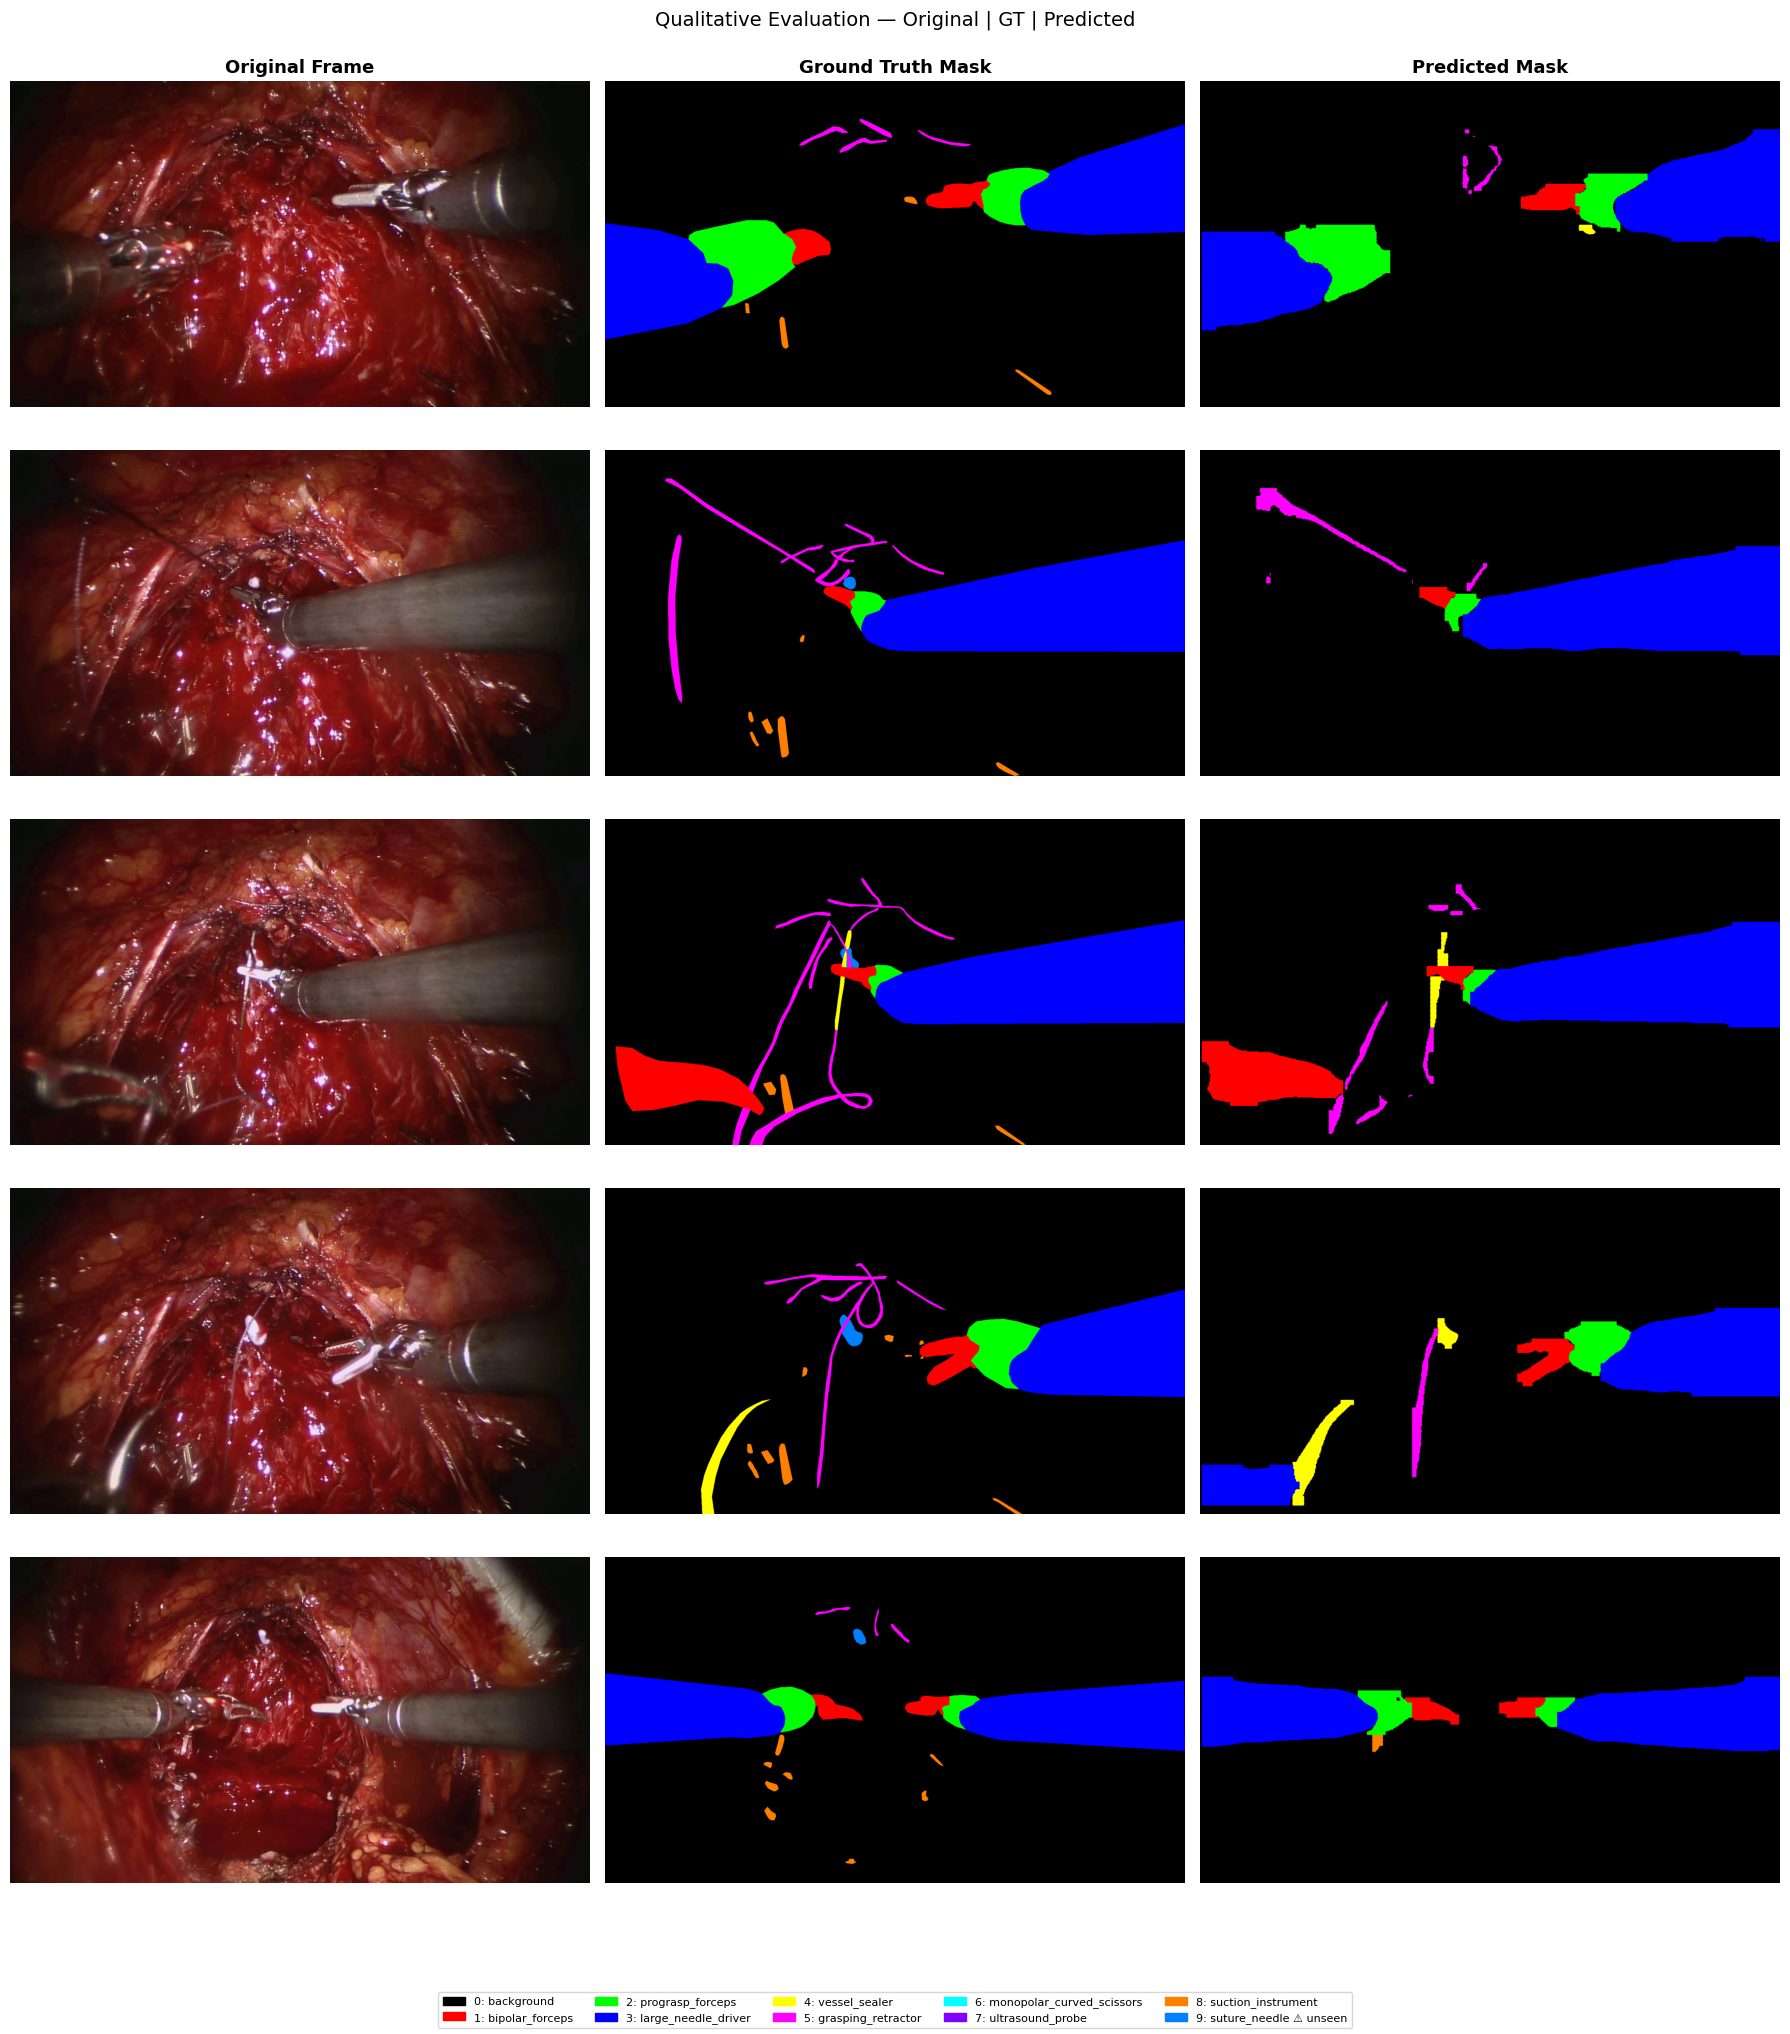

In [40]:
n_show = 5
indices = np.linspace(0, len(test_images) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(18, 4 * n_show))
col_titles = ['Original Frame', 'Ground Truth Mask', 'Predicted Mask']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for row, idx in enumerate(indices):
    frame = cv2.cvtColor(cv2.imread(str(test_images[idx])), cv2.COLOR_BGR2RGB)
    gt   = colorize_mask(gt_masks_all[idx])
    pred = colorize_mask(pred_semantic_all[idx])
    for col, img in enumerate([frame, gt, pred]):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(test_images[idx].name, fontsize=8, rotation=0,
                             labelpad=80, va='center')

legend_patches = [
    mpatches.Patch(color=np.array(c)/255,
                   label=f'{i}: {CLASS_NAMES[i]}' + (' ⚠ unseen' if i == 9 else ''))
    for i, c in CLASS_COLORS.items()
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=8, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.suptitle('Qualitative Evaluation — Original | GT | Predicted', y=1.01, fontsize=14)
plt.savefig(Path(CONFIG['results_dir']) / 'train' / 'overlay_comparisons.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [41]:
summary = {
    'miou':                float(miou),
    'miou_no_background':  float(miou_no_bg),
    'pixel_accuracy':      float(pixel_acc),
    'per_class_iou': {
        CLASS_NAMES[c]: (float(per_class_iou[c]) if not np.isnan(per_class_iou[c]) else None)
        for c in range(n_classes)
    },
    'test_frames':     len(gt_masks_all),
    'num_classes':     n_classes,
    'unseen_classes':  [9],
    'checkpoint':      str(best_ckpt),
    'test_video':      CONFIG['test_video'],
}

summary_path = Path(CONFIG['results_dir']) / 'train' / 'evaluation_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'[OK] Evaluation summary saved to {summary_path}')

[OK] Evaluation summary saved to runs\segment\results\train\evaluation_summary.json


---
## Section 5 — Summary & Next Steps

In [42]:
print('=' * 65)
print('YOLOv8 SAR-RARP50 — Training & Evaluation Summary')
print('=' * 65)
print(f'Checkpoint:          {best_ckpt}')
print(f'Test set:            {CONFIG["test_video"]} ({len(gt_masks_all)} frames)')
print(f'mIoU (all):          {miou:.4f}')
print(f'mIoU (no bg):        {miou_no_bg:.4f}')
print(f'Pixel accuracy:      {pixel_acc:.4f}')
print()
print(f'{"Class":35s}  {"IoU":>7}')
print('-' * 45)
for c in range(n_classes):
    iou_v  = per_class_iou[c]
    note   = ' (unseen)' if c == 9 else ''
    iou_s  = f'{iou_v:.4f}' if not np.isnan(iou_v) else '   N/A '
    print(f'{c}: {CLASS_NAMES[c]:30s}  {iou_s}{note}')
print()
print('Next: open notebooks/video_mvp.ipynb for the video demo!')

YOLOv8 SAR-RARP50 — Training & Evaluation Summary
Checkpoint:          runs\segment\results\train\weights\best.pt
Test set:            video_12 (132 frames)
mIoU (all):          0.3889
mIoU (no bg):        0.3283
Pixel accuracy:      0.9363

Class                                    IoU
---------------------------------------------
0: background                      0.9344
1: bipolar_forceps                 0.5566
2: prograsp_forceps                0.6356
3: large_needle_driver             0.8482
4: vessel_sealer                   0.2777
5: grasping_retractor              0.1437
6: monopolar_curved_scissors       0.0344
7: ultrasound_probe                0.4359
8: suction_instrument              0.0224
9: suture_needle                   0.0000 (unseen)

Next: open notebooks/video_mvp.ipynb for the video demo!
